# 6 · Intertidal elevation map

Page 5 explained **NDWI** — the wet/dry index that links satellite reflectance to tide
height. This page goes the final step: it estimates the **tidal flat elevation (m, MSL)** for every
individual pixel.

**What this notebook answers**

1. Do we have **enough clear scenes** over the chosen window?
2. Which **tide levels** do those scenes actually sample?
3. What does the **elevation map** look like, and where is the fit **uncertain**?

**The method in one paragraph**

For every pixel, the algorithm collects all clear satellite observations (Landsat, Sentinel-2, or both) over the multi-year
window, tags each with its FES2022 tide height, and finds the tide level at which the pixel
switches from dry (NDWI < 0) to wet (NDWI > 0). That **crossover tide height is the
elevation** of the sediment surface. Because each pixel is fitted independently from dozens
of observations, the result also carries a per-pixel **uncertainty**.

**Choosing the time window**

The single most important parameter on this page is the length of the time window (`START` to `END`). It controls a fundamental trade-off:

- **A longer window** gives more satellite observations per pixel, and — crucially — more different tide levels. The crossover fit requires the pixel to be observed both dry and wet across a good spread of the tidal range; more years increase the chance of capturing the high and low extremes. The cost is that you assume the flat did not change shape over that period. Over 5 years, a mobile sandbank or a migrating channel may have moved by tens of metres, and the fit then averages over a surface that no longer exists as a single entity.

- **A shorter window** is more faithful to a single morphological "snapshot" and is what you want if your goal is change detection between epochs. But with fewer observations, the fit is noisier, the uncertainty layer grows, and pixels near the tidal extremes may not be constrained at all.

The right length depends on your sensor mix and your research question:

| Window | When to use it | Watch out for |
|---|---|---|
| 1 year | Sentinel-2 only, or a dense Landsat 8+9 site; a clean single-epoch snapshot | Often too few clear scenes with Landsat alone — check Step 6 |
| 3 years | The Landsat-only default — usually the minimum for stable coverage of the full tidal range | Assumes ~3 years of morphological stability |
| 5 years | Sparse or cloudy sites; reaching the tidal extremes | Risk of averaging across real morphological change |

**Pipeline**

| Step | Action |
|---|---|
| 5 | Download Landsat or Sentinel-2 → NDWI stack (cached per year) |
| 6 | Tide × satellite plot (FES2022 curve + scene dots) |
| 7 | Run `elevation()` — fit a height for each pixel |
| 8 | Map elevation + uncertainty |
| 9 | QA layers (NDWI–tide correlation, wet frequency, clear count) |
| 10 | Export NetCDF / GeoTIFF |

**Key outputs**

| Variable | Meaning |
|---|---|
| `elevation` | Elevation (m, MSL) of intertidal flats |
| `elevation_uncertainty` | Fit uncertainty (m) — **lower is better** |
| `qa_ndwi_freq` | Fraction of clear observations that were wet |
| `qa_count_clear` | Number of clear observations per pixel |

**Rule of thumb:**

- **Landsat only** — **3–4 years**, **≥ 20 clear scenes**; 30 m.
- **Sentinel-2 only** — often **1–2 years**; 10 m (heavier download).
- **Both** — best tidal sampling (page 3); combined on a **30 m** grid (S2 resampled).

Always read the Step 6 sampling plot before trusting the map.

> **Heavy step:** the first run downloads several GB of imagery (more for Sentinel-2 at 10 m).
> Step 7 loads the full stack into memory. Keep `DELTA` modest (~0.08° ≈ 8 km) while learning.

**Previous:** [5 · NDWI](05_ndwi.ipynb)

## Step 1 — Imports

Libraries for this page:

- **`pystac_client` + `planetary_computer`** — search and sign Landsat or Sentinel-2 STAC items (page 2).
- **`odc.stac`** — load reflectance bands into lazy xarray/Dask arrays.
- **`dea_tools.dask`** — start a local Dask cluster for parallel download and resampling.
- **`intertidal.elevation`** — the DEA production elevation algorithm.
- **`cache_utils`** — shared FES2022 tide cache + datetime helper (pages 3–4).
- **`rioxarray`** — GeoTIFF export in Step 10.

In [10]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import odc.stac
import planetary_computer
import pystac_client
import rioxarray  # noqa: F401 — registers the .rio accessor used in Step 10

from dea_tools.dask import create_local_dask_cluster
from intertidal.elevation import elevation
from cache_utils import load_or_compute_tides, _utc_datetime_ns

warnings.filterwarnings("ignore")

# All saved figures and exports go into outputs/
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Imports OK.")

Imports OK.


## Step 2 — Configuration

Use the **same site centre** as pages 3–4 (`LON`, `LAT`, `SITE_NAME`).

Enable **one or both** sensors with the toggles below (same idea as page 3). You can run
Landsat alone, Sentinel-2 alone, or **both together** for denser tidal sampling.

| Toggle | Product | Native resolution |
|---|---|---|
| `USE_LANDSAT` | Landsat C2 L2 | 30 m |
| `USE_SENTINEL2` | Sentinel-2 L2A (harmonised) | 10 m |

When **both** are enabled, stacks are merged on a common **30 m** grid (Sentinel-2 is
resampled to match Landsat). That trades S2 sharpness for a single NDWI time series
with more tide levels — usually the best choice for the elevation fit.

Sentinel-2 scenes after **Processing Baseline 04.00** (Jan 2022+) carry a +1000 DN
offset; the loader harmonises them before NDWI (same as elsewhere in the tutorial).

| Variable | Role |
|---|---|
| `USE_LANDSAT` / `USE_SENTINEL2` | Which sensors to download and fit |
| `DELTA` | Half-width of the bounding box in degrees (~0.08° ≈ 8 km side) |
| `START` / `END` | Analysis window |
| `MAX_CLOUD` | Scene-level cloud ceiling passed to the STAC search |
| `MIN_SCENES_RELIABLE` | Warning if total scene count falls below this |
| `OVERWRITE` | `True` re-downloads cached years |
| `TIDE_DIR` / `TIDE_MODEL` | FES2022 files (same as pages 3–4) |


In [12]:
# === EDIT THESE ===
LON        = 4.81050
LAT        = 52.98886
SITE_NAME  = "WaddenSea"

USE_LANDSAT    = True
USE_SENTINEL2  = False   # set True to combine with Landsat (30 m grid)

DELTA      = 0.08
START      = "2023-01-01"
END        = "2025-12-31"

TIDE_DIR   = "./tide_models"
TIDE_MODEL = "FES2022"

MAX_CLOUD  = 80
MIN_SCENES_RELIABLE = 20
OVERWRITE  = False

# Step 7: avoid slow/brittle pixel_tides() — use one FES2022 height per scene (default)
USE_PIXEL_TIDES = False
N_DASK_WORKERS = None        # None = auto (~ CPU − 1) for sat_ds.compute()
N_ELEVATION_WORKERS = None   # None = all cores for elevation() rolling median

SENSORS = [tag for tag, use in [("landsat", USE_LANDSAT), ("sentinel-2", USE_SENTINEL2)] if use]
if not SENSORS:
    raise ValueError("Enable at least one sensor (USE_LANDSAT and/or USE_SENTINEL2).")

if len(SENSORS) == 2:
    RESOLUTION = 30
    SENSOR_LABEL = "Landsat + Sentinel-2"
elif USE_LANDSAT:
    RESOLUTION = 30
    SENSOR_LABEL = "Landsat"
else:
    RESOLUTION = 10
    SENSOR_LABEL = "Sentinel-2"

SENSOR_TAGS = {"landsat": "landsat", "sentinel-2": "s2"}

os.environ["EO_TIDES_TIDE_MODELS"] = TIDE_DIR
BBOX = (LON - DELTA, LAT - DELTA, LON + DELTA, LAT + DELTA)
CACHE_DIR = Path("cache") / f"elevation_{SITE_NAME}"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
YEARS = list(range(int(START[:4]), int(END[:4]) + 1))

print(f"Site    : {SITE_NAME}  ({LAT:.4f} N, {LON:.4f} E)")
print(f"Sensors : {SENSOR_LABEL}  (output grid {RESOLUTION} m)")
print(f"AOI     : {BBOX}")
print(f"Window  : {START} to {END}  ({len(YEARS)} calendar years)")
print(f"Cache   : {CACHE_DIR}")
print(f"Tides   : {'pixel_tides (per pixel)' if USE_PIXEL_TIDES else 'per-scene FES2022 (recommended)'}")


Site    : WaddenSea  (52.9889 N, 4.8105 E)
Sensors : Landsat  (output grid 30 m)
AOI     : (4.7305, 52.908860000000004, 4.8905, 53.06886)
Window  : 2025-01-01 to 2025-12-31  (1 calendar years)
Cache   : cache/elevation_WaddenSea
Tides   : per-scene FES2022 (recommended)


## Step 3 — Start a local Dask cluster

The elevation method needs many satellite scenes. If you tried to load all of those into memory at once as ordinary arrays, your computer would run out of RAM almost immediately: a single multi-year stack for even a modest area can be tens of gigabytes. We need a way to work with data that is larger than memory.

**Dask** is a Python library for parallel and out-of-core computing — "out-of-core" meaning it can process datasets that do not fit in RAM. It does this with two ideas:

- **Chunking**. Instead of one giant array, Dask splits the data into smaller blocks ("chunks") — here, tiles of 2048 × 2048 pixels. Only a few chunks are ever in memory at the same time.
- **Lazy evaluation**. When you call odc.stac.load(), Dask does not download anything yet. It builds a task graph — a recipe describing which files to read, how to mask clouds, how to compute NDWI — and returns a placeholder array. The actual work only happens later, when you explicitly ask for the result (in Step 7, with .compute()). This lets Dask plan the whole computation efficiently before doing any of it.

A Dask "cluster" is just a set of worker processes that execute the task graph. The local cluster runs those workers on your own machine, one per CPU core. So if your laptop has 8 cores, Dask can download and resample 8 scene-chunks simultaneously instead of one at a time — a large speedup for the I/O-heavy work of pulling scenes from Planetary Computer and reprojecting them to a common 30 m UTM grid.

(The same code scales to a real distributed cluster across many machines, but for this tutorial a local cluster on one computer is all you need.)

When you run the cell, you will see a `<Client: ...>` summary with the number of workers and the total memory available to them. It also prints a dashboard link (usually `http://127.0.0.1:8787`) — open it in a browser if you want to watch the download and computation progress live as coloured task bars. You can safely ignore it; it is purely a monitor.

*You only start the cluster once per notebook session. If you re-run this cell, Dask will reuse or restart the cluster — that is harmless.*

In [13]:
import os

_cpu = os.cpu_count() or 4
_n_dask = N_DASK_WORKERS if N_DASK_WORKERS is not None else max(1, _cpu - 1)

client = create_local_dask_cluster(n_workers=_n_dask, return_client=True)
print(f"Dask cluster ready — {_n_dask} worker(s)")
print(f"Dashboard: {client.dashboard_link}")


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:53369/status,
Dashboard: http://127.0.0.1:53369/status,Workers: 11
Total threads: 132,Total memory: 15.20 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:53371,Workers: 0
Dashboard: http://127.0.0.1:53369/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:53502,Total threads: 12
Dashboard: http://127.0.0.1:53509/status,Memory: 1.38 GiB
Nanny: tcp://127.0.0.1:53379,


Dask cluster ready — 11 worker(s)
Dashboard: http://127.0.0.1:53369/status


## Step 4 — Helper functions

These functions wrap the sensor → NDWI pipeline so the steps below stay short and
readable. Read the comments inside each one to understand what it does — you do not need
to change them.

| Function | Purpose |
|---|---|
| `cache_sensor_year` / loaders | STAC search → reflectance → cloud mask → NDWI (+ NDVI) |
| `cache_year` | Download one calendar year and save it to a Zarr store |
| `load_scene_table` | Merge the per-year scene-metadata CSVs |
| `tag_scenes_with_tide` | Attach an FES2022 tide height to each scene timestamp |

### What is a Zarr store, and why cache to one?

Downloading and processing a year of satellite imagery is slow — it pulls gigabytes from Planetary Computer and reprojects every scene to a common grid. We do not want to repeat that work every time we re-run the notebook. So after processing each year once, we save the result to disk and simply reload it next time. The format we save to is **Zarr**.

Zarr is a storage format designed for **large, chunked, multi-dimensional arrays** — exactly the kind of data we have here (an x × y × time stack of NDWI values). A few properties make it the right choice:

- **It stores chunks as separate files**. Remember from Step 3 that Dask splits arrays into blocks. Zarr writes each block to its own file on disk. This means Dask can read just the chunks it needs, in parallel, without loading the whole array — the on-disk format mirrors the in-memory model.
- **It preserves the full xarray structure**. Coordinates, dimension names, the time axis, and the coordinate reference system are all kept, so when we reopen a Zarr store with xr.open_zarr() we get back exactly the labelled dataset we saved — no manual reconstruction.
- **It reopens lazily**. xr.open_zarr() returns a Dask-backed array, just like the original load. The cached data stays on disk until a computation actually needs it, so reopening many years of cache costs almost nothing until Step 7.

You can think of Zarr here as a "save game" for the expensive download step. Other formats could store the same numbers — NetCDF, or a stack of GeoTIFFs — but Zarr's one-file-per-chunk design fits Dask's parallel, larger-than-memory workflow most naturally.

### Why cache per calendar year?

`cache_year` deliberately saves one Zarr store per year (`ndwi_2023.zarr`, `ndwi_2024.zarr`, …) rather than one big file for the whole window. This is what makes the time-window experiment from the intro cheap: extending `END` from 2023 to 2025 only triggers the download of the two new years — the years you already cached are reused instantly. Each year also gets a small scenes_<year>.csv listing the scene timestamps, which Step 6 uses for the tidal-sampling plot.

The Zarr stores live in `cache/elevation_<site>/`. They can be large (hundreds of MB to several GB per year). Safe to delete to reclaim space — the next run simply rebuilds them — and they should **not** be committed to git.

In [14]:
PC_URL = "https://planetarycomputer.microsoft.com/api/stac/v1"

# SCL classes to mask: 0 nodata, 1 defective, 3 shadow, 7 unclassified, 8–10 cloud/cirrus
SCL_MASK_VALUES = {0, 1, 3, 7, 8, 9, 10}
S2_BASELINE_CUTOFF = np.datetime64("2022-01-25")


def _chunk_xy() -> int:
    return 2048 if RESOLUTION >= 30 else 1024


def harmonize_s2(ds: xr.Dataset) -> xr.Dataset:
    """Subtract +1000 DN offset for Sentinel-2 Processing Baseline >= 04.00."""
    bands = [v for v in ds.data_vars if v != "SCL"]
    if not bands:
        return ds

    def _subtract_1000(data: xr.Dataset) -> xr.Dataset:
        out = data.copy()
        out[bands] = out[bands] - 1000
        return out.clip(min=0)

    if "time" not in ds.dims:
        if "time" in ds.coords:
            t = np.datetime64(ds.coords["time"].values)
            return _subtract_1000(ds) if t > S2_BASELINE_CUTOFF else ds.clip(min=0)
        return ds.clip(min=0)

    times = ds.time.values
    if np.all(times <= S2_BASELINE_CUTOFF):
        return ds.clip(min=0)
    if np.all(times > S2_BASELINE_CUTOFF):
        return _subtract_1000(ds)

    mask = xr.DataArray(times > S2_BASELINE_CUTOFF, dims=["time"], coords={"time": ds.time})
    out = ds.copy()
    for band in bands:
        out[band] = xr.where(mask, out[band] - 1000, out[band]).clip(min=0)
    return out


def apply_s2_cloud_mask(ds: xr.Dataset) -> xr.Dataset:
    scl = ds["SCL"]
    cloud_mask = xr.zeros_like(scl, dtype=bool)
    for val in SCL_MASK_VALUES:
        cloud_mask = cloud_mask | (scl == val)
    return ds.where(~cloud_mask).drop_vars("SCL", errors="ignore")


def apply_landsat_cloud_mask(ds: xr.Dataset) -> xr.Dataset:
    """Landsat C2 L2 QA_PIXEL mask (CFMask).

    Masks fill, dilated cloud, cirrus, cloud, and cloud shadow. Bit 1 (dilated cloud)
    in particular reduces edge noise over water that bit 3 alone often misses.
    See USGS Collection 2 QA_PIXEL bit index.
    """
    qa = ds["qa_pixel"]
    bad = (
        np.bitwise_and(qa, 1 << 0)  # fill
        | np.bitwise_and(qa, 1 << 1)  # dilated cloud
        | np.bitwise_and(qa, 1 << 2)  # cirrus
        | np.bitwise_and(qa, 1 << 3)  # cloud
        | np.bitwise_and(qa, 1 << 4)  # cloud shadow
    )
    return ds.where(bad == 0).drop_vars("qa_pixel", errors="ignore")


def load_landsat_ndwi(start: str, end: str):
    """Download Landsat C2 L2 scenes and return an NDWI (+ NDVI) xarray stack."""
    catalog = pystac_client.Client.open(PC_URL, modifier=planetary_computer.sign_inplace)

    search = catalog.search(
        collections=["landsat-c2-l2"],
        bbox=BBOX,
        datetime=f"{start}/{end}",
        query={
            "eo:cloud_cover": {"lt": MAX_CLOUD},
            "platform": {"in": ["landsat-5", "landsat-7", "landsat-8", "landsat-9"]},
            "landsat:collection_category": {"in": ["T1"]},
        },
    )
    items = search.item_collection()
    if len(items) == 0:
        return None, items

    ds = odc.stac.load(
        items,
        bands=["red", "green", "nir08", "qa_pixel"],
        bbox=BBOX,
        crs="utm",
        resolution=RESOLUTION,
        chunks={"x": _chunk_xy(), "y": _chunk_xy()},
        groupby="solar_day",
        resampling={"qa_pixel": "nearest", "*": "cubic"},
        fail_on_error=False,
    )

    ds = apply_landsat_cloud_mask(ds)
    ds = (ds.where(ds != 0) * 0.0000275 - 0.2).clip(0, 1)

    ndwi = ((ds.green - ds.nir08) / (ds.green + ds.nir08)).rename("ndwi")
    ndvi = ((ds.nir08 - ds.red) / (ds.nir08 + ds.red)).rename("ndvi")
    return xr.Dataset({"ndwi": ndwi, "ndvi": ndvi}), items


def load_sentinel2_ndwi(start: str, end: str):
    """Download Sentinel-2 L2A (harmonised) and return an NDWI (+ NDVI) xarray stack."""
    catalog = pystac_client.Client.open(PC_URL, modifier=planetary_computer.sign_inplace)

    search = catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=BBOX,
        datetime=f"{start}/{end}",
        query={"eo:cloud_cover": {"lt": MAX_CLOUD}},
    )
    items = search.item_collection()
    if len(items) == 0:
        return None, items

    ds = odc.stac.load(
        items,
        bands=["red", "green", "nir", "SCL"],
        bbox=BBOX,
        crs="utm",
        resolution=RESOLUTION,
        chunks={"x": _chunk_xy(), "y": _chunk_xy()},
        groupby="time",
        resampling={"SCL": "nearest", "*": "cubic"},
        fail_on_error=False,
    )

    ds = harmonize_s2(ds)
    ds = apply_s2_cloud_mask(ds)
    ds = (ds / 10000.0).clip(0, 1)

    ndwi = ((ds.green - ds.nir) / (ds.green + ds.nir)).rename("ndwi")
    ndvi = ((ds.nir - ds.red) / (ds.nir + ds.red)).rename("ndvi")
    return xr.Dataset({"ndwi": ndwi, "ndvi": ndvi}), items


LOADERS = {
    "landsat": load_landsat_ndwi,
    "sentinel-2": load_sentinel2_ndwi,
}


def combine_ndwi_stacks(parts: list[xr.Dataset]) -> xr.Dataset:
    """Concatenate sensor/year stacks on time; align grids if needed."""
    if not parts:
        raise ValueError("No NDWI stacks to combine.")
    if len(parts) == 1:
        return parts[0]
    ref = parts[0]
    aligned = [ref]
    for ds in parts[1:]:
        aligned.append(ds.reindex_like(ref, method="nearest"))
    return xr.concat(aligned, dim="time").sortby("time")


def cache_sensor_year(sensor: str, year: int, overwrite: bool = False):
    """Cache one calendar year for one sensor; return (path, n_scenes)."""
    tag = SENSOR_TAGS[sensor]
    zpath = CACHE_DIR / f"ndwi_{tag}_{year}.zarr"
    meta  = CACHE_DIR / f"scenes_{tag}_{year}.csv"

    if zpath.exists() and not overwrite:
        n = len(pd.read_csv(meta)) if meta.exists() else np.nan
        print(f"  {year} {tag}: cache hit ({int(n) if n == n else '?'} scenes)")
        return zpath, n

    label = "Landsat" if sensor == "landsat" else "Sentinel-2"
    print(f"  {year} {tag}: downloading {label} ...")
    ds, items = LOADERS[sensor](f"{year}-01-01", f"{year}-12-31")
    n = len(items)
    if ds is None or n == 0:
        print(f"  {year} {tag}: no scenes")
        return None, 0

    pd.DataFrame({
        "time":        [it.properties.get("datetime") for it in items],
        "platform":    [it.properties.get("platform", "?") for it in items],
        "sensor":      sensor,
        "cloud_cover": [it.properties.get("eo:cloud_cover", np.nan) for it in items],
    }).to_csv(meta, index=False)

    c = _chunk_xy()
    ds = ds.chunk({"time": -1, "x": c, "y": c})
    ds.to_zarr(zpath, mode="w")
    print(f"  {year} {tag}: cached {n} scenes → {zpath.name}")
    return zpath, n


def load_scene_table() -> pd.DataFrame:
    """Combine all scenes_<sensor>_<year>.csv files from Step 5."""
    frames = []
    for sensor in SENSORS:
        tag = SENSOR_TAGS[sensor]
        for year in YEARS:
            meta = CACHE_DIR / f"scenes_{tag}_{year}.csv"
            if meta.exists():
                df = pd.read_csv(meta)
                df["time"] = _utc_datetime_ns(df["time"])
                frames.append(df)
    if not frames:
        raise FileNotFoundError("No scenes_*.csv files — run Step 5 first.")
    return pd.concat(frames, ignore_index=True).sort_values("time")


def tag_scenes_with_tide(scenes: pd.DataFrame, tide_series: pd.Series) -> pd.DataFrame:
    """Nearest FES2022 tide height (±30 min) for each scene acquisition time."""
    tide_df = tide_series.rename("tide_height").reset_index()
    tide_df.columns = ["time", "tide_height"]
    tide_df["time"] = _utc_datetime_ns(tide_df["time"])

    out = scenes.copy()
    out["time"] = _utc_datetime_ns(out["time"])
    out = out.sort_values("time")

    tagged = pd.merge_asof(
        out,
        tide_df.sort_values("time"),
        on="time",
        direction="nearest",
        tolerance=pd.Timedelta("30min"),
    )
    return tagged


def build_scene_tide_data(sat_ds: xr.Dataset, tide_series: pd.Series) -> xr.DataArray:
    """One FES2022 height per satellite timestep (site point).

    Pass to elevation(tide_data=...) to skip pixel_tides() — faster and avoids
    eo_tides MultiIndex errors on combined Landsat+S2 stacks.
    """
    tide_df = tide_series.rename("tide_m").reset_index()
    tide_df.columns = ["time", "tide_m"]
    tide_df["time"] = _utc_datetime_ns(tide_df["time"])

    times = pd.DataFrame({"time": _utc_datetime_ns(sat_ds.time.values)}).sort_values("time")
    tagged = pd.merge_asof(
        times,
        tide_df.sort_values("time"),
        on="time",
        direction="nearest",
        tolerance=pd.Timedelta("30min"),
    )
    if tagged["tide_m"].isna().any():
        raise ValueError(
            f"{int(tagged['tide_m'].isna().sum())} scene time(s) lack FES2022 within ±30 min."
        )
    return xr.DataArray(
        tagged["tide_m"].values,
        dims=["time"],
        coords={"time": sat_ds.time},
        name="tide_m",
    )


## Step 5 — Build the NDWI time series (year caches)

For each **enabled sensor** and **calendar year** we cache:

- `ndwi_<landsat|s2>_<year>.zarr` — NDWI stack for that sensor and year
- `scenes_<landsat|s2>_<year>.csv` — scene timestamps for Step 6

All enabled sensors are then merged into **one chronological stack** on the output grid
(`RESOLUTION` m) and passed to `elevation()` in Step 7.


In [15]:
parts, scene_counts = [], []

for year in YEARS:
    for sensor in SENSORS:
        path, n = cache_sensor_year(sensor, year, overwrite=OVERWRITE)
        scene_counts.append(n if n == n else 0)
        if path is not None:
            parts.append(xr.open_zarr(path))

n_scenes = int(sum(scene_counts))
print(f"\nTotal clear-scene passes in window: {n_scenes}")
for sensor in SENSORS:
    tag = SENSOR_TAGS[sensor]
    n_s = sum(
        len(pd.read_csv(CACHE_DIR / f"scenes_{tag}_{y}.csv"))
        for y in YEARS
        if (CACHE_DIR / f"scenes_{tag}_{y}.csv").exists()
    )
    print(f"  {tag}: {n_s} scenes")

if not parts:
    raise SystemExit(
        f"No data for {SENSOR_LABEL} — widen dates/AOI, raise MAX_CLOUD, or check toggles."
    )

sat_ds = combine_ndwi_stacks(parts)
print("Combined stack:", dict(sat_ds.sizes))

flags = []
if n_scenes < MIN_SCENES_RELIABLE:
    flags.append(
        f"FEW SCENES ({n_scenes} < {MIN_SCENES_RELIABLE}) — elevation fit may be noisy"
    )
status = "OK" if not flags else "WARNING"
print("=" * 60)
print(f"[{status}] Scene count — {SITE_NAME} ({SENSOR_LABEL})")
for f in flags:
    print(f"  ⚠  {f}")
if not flags:
    print("  ✓  Enough scenes for a stable elevation fit.")
print("=" * 60)


  2025 landsat: downloading Landsat ...


/Users/timgrandjean/Documents/NIOZ/NCK/.venv/lib/python3.12/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(
/Users/timgrandjean/Documents/NIOZ/NCK/.venv/lib/python3.12/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(
/Users/timgrandjean/Documents/NIOZ/NCK/.venv/lib/python3.12/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(
/Users/timgrandjean/Documents/NIOZ/NCK/.venv/lib/python3.12/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(
/Users/timgrandjean/Documents/NIOZ/NCK/.venv/lib/python3.12/site-packages/rasterio/warp.py:387: NotGeore

  2025 landsat: cached 57 scenes → ndwi_landsat_2025.zarr

Total clear-scene passes in window: 57
  landsat: 57 scenes
Combined stack: {'time': 57, 'y': 603, 'x': 374}
[OK] Scene count — WaddenSea (Landsat)
  ✓  Enough scenes for a stable elevation fit.


> **Reading Step 5:**
>
> | Output | Good sign | Warning sign |
> |---|---|---|
> | **Scenes per year** | Several per year | Zero for a year → gap in the stack |
> | **Total scenes** | ≥ 20 | < 20 → noisy fits; extend the window |
> | **Cache hit** | Instant reload on re-run | First run downloads GB of data |
> | **Stack shape** | `time` ≈ total scenes | `time` = 0 → check the STAC filters |
>
> If you get a WARNING: extend `END`, raise `MAX_CLOUD`, or revisit the page 3 feasibility check.

## Step 6 — Tide × satellite acquisitions

This is the **same plot as page 3**, now for the full multi-year stack from Step 5: the grey
curve is FES2022; coloured dots are clear **Landsat or Sentinel-2** passes at the tide heights
`elevation()` will assign to each scene.

| Line / band | Meaning |
|---|---|
| **Grey curve** | FES2022 tide (30 min) |
| **Coloured dots** | Clear scenes at acquisition-time tide height |
| **Red dashed (HAT)** | Highest astronomical tide in the window |
| **Blue dashed (LAT)** | Lowest astronomical tide |
| **Red/blue shading** | Portions of the tidal range **not** sampled by any satellite |

Wide shaded bands mean the algorithm must **extrapolate** beyond the observed tide levels —
exactly where elevation uncertainty will be highest.


  Loaded from cache ← cache/tides_WaddenSea_2025-01-01_2025-12-31.parquet  (17,473 rows)
HAT +1.098 m  |  LAT -1.163 m  |  range 2.261 m
HOT +0.960 m  |  LOT -0.918 m
Unsampled above HOT: 0.138 m (6% of range)
Unsampled below LOT: 0.245 m (11% of range)


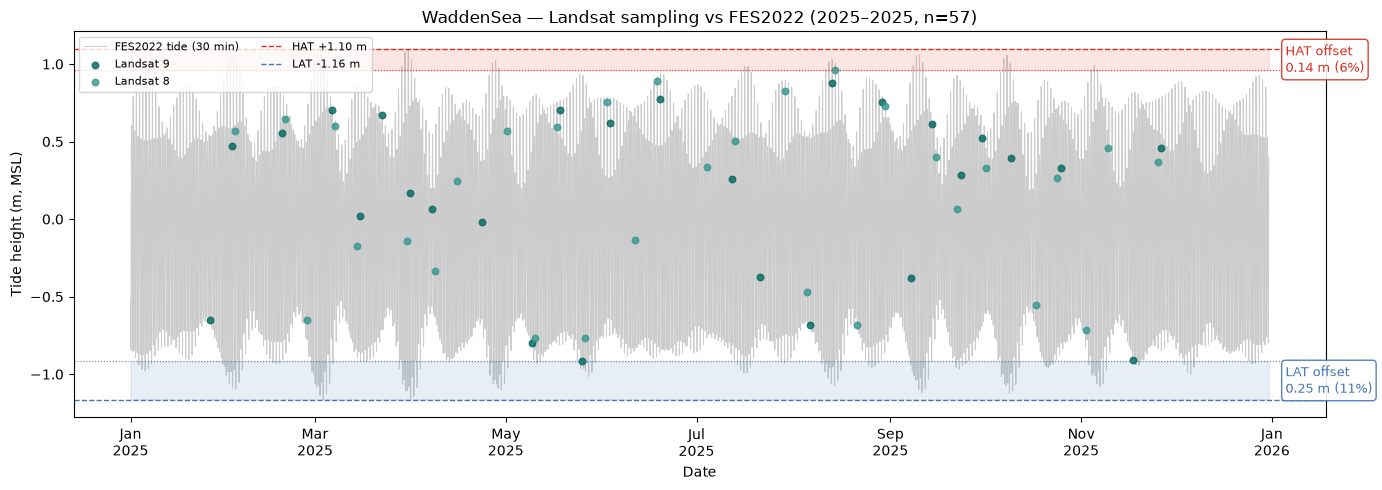

Saved: outputs/WaddenSea_tidal_sampling_elevation.png


In [16]:
# Continuous FES2022 series (reuses the page 3-4 cache if the window matches)
tide_series = load_or_compute_tides(
    lon=LON, lat=LAT,
    start=START, end=END,
    site_name=SITE_NAME,
    tide_model=TIDE_MODEL,
    tide_dir=TIDE_DIR,
    overwrite=False,
)

# Tag each scene with the nearest modelled tide height
scenes_df = tag_scenes_with_tide(load_scene_table(), tide_series)
obs = scenes_df["tide_height"].dropna()
if obs.empty:
    raise ValueError("No scenes with tide heights — check FES2022 / tide_models.")

# Reference levels (same definitions as page 3)
hat  = float(tide_series.max())   # Highest Astronomical Tide (model)
lat_ = float(tide_series.min())   # Lowest Astronomical Tide (model)
hot  = float(obs.max())           # Highest Observed Tide (satellite)
lot  = float(obs.min())           # Lowest Observed Tide (satellite)
tr   = hat - lat_                 # full astronomical range

# How much of the range was never imaged, above HOT and below LOT?
offset_high_m   = hat - hot
offset_low_m    = lot - lat_
offset_high_pct = offset_high_m / tr if tr > 0 else float("nan")
offset_low_pct  = offset_low_m  / tr if tr > 0 else float("nan")

print(f"HAT {hat:+.3f} m  |  LAT {lat_:+.3f} m  |  range {tr:.3f} m")
print(f"HOT {hot:+.3f} m  |  LOT {lot:+.3f} m")
print(f"Unsampled above HOT: {offset_high_m:.3f} m ({offset_high_pct:.0%} of range)")
print(f"Unsampled below LOT: {offset_low_m:.3f} m ({offset_low_pct:.0%} of range)")

# --- plot ---
# One colour per platform (Landsat or Sentinel-2)
platform_colors = {
    "landsat-5": "#8c510a",
    "landsat-7": "#bf812d",
    "landsat-8": "#35978f",
    "landsat-9": "#01665e",
    "sentinel-2a": "#2ca02c",
    "sentinel-2b": "#98df8a",
    "sentinel-2c": "#31a354",
}


def _platform_label(name: str) -> str:
    if name.startswith("landsat-"):
        return name.replace("landsat-", "Landsat ")
    if name.startswith("sentinel-"):
        return "Sentinel-" + name.split("-", 1)[1].upper()
    return name

fig, ax = plt.subplots(figsize=(14, 5))

# Background: full FES2022 tide curve
tide_ts = tide_series.copy()
tide_ts.index = pd.to_datetime(tide_ts.index, utc=True)
ax.plot(
    tide_ts.index, tide_ts.values,
    color="#cccccc", lw=0.7, zorder=0, label="FES2022 tide (30 min)",
)

# Overlay each platform's overpasses at their tide height
for platform in scenes_df["platform"].unique():
    sub = scenes_df.loc[scenes_df["platform"] == platform]
    ax.scatter(
        sub["time"], sub["tide_height"], s=22, alpha=0.8,
        color=platform_colors.get(platform, "grey"),
        label=_platform_label(platform), zorder=2,
    )

# HAT/LAT (model extremes, dashed) and HOT/LOT (observed extremes, dotted)
ax.axhline(hat,  color="#d7301f", lw=1.0, ls="--", label=f"HAT {hat:+.2f} m")
ax.axhline(lat_, color="#4575b4", lw=1.0, ls="--", label=f"LAT {lat_:+.2f} m")
ax.axhline(hot,  color="#d7301f", lw=0.8, ls=":",  alpha=0.9)
ax.axhline(lot,  color="#4575b4", lw=0.8, ls=":",  alpha=0.9)

# Shaded "unsampled" bands with annotation boxes (page 3 style)
x_annot = tide_ts.index.max()
for y0, y1, col, txt in [
    (hot, hat,  "#d7301f", f"HAT offset\n{offset_high_m:.2f} m ({offset_high_pct:.0%})"),
    (lat_, lot, "#4575b4", f"LAT offset\n{offset_low_m:.2f} m ({offset_low_pct:.0%})"),
]:
    ax.fill_between(tide_ts.index, y0, y1, color=col, alpha=0.12, zorder=1)
    ax.annotate(
        txt, xy=(x_annot, (y0 + y1) / 2), xytext=(12, 0),
        textcoords="offset points", va="center", ha="left", fontsize=9, color=col,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=col, alpha=0.9),
    )

ax.set_xlabel("Date")
ax.set_ylabel("Tide height (m, MSL)")
ax.set_title(
    f"{SITE_NAME} — {SENSOR_LABEL} sampling vs FES2022 "
    f"({START[:4]}–{END[:4]}, n={len(scenes_df)})"
)
ax.legend(fontsize=8, ncol=2, loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"{SITE_NAME}_tidal_sampling_elevation.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: outputs/{SITE_NAME}_tidal_sampling_elevation.png")

> **Reading Step 6:**
>
> | Pattern | Meaning | Action |
> |---|---|---|
> | Dots **spread along the grey curve** | Good tidal coverage | Proceed to Step 7 |
> | **Large shaded bands** | HAT/LAT extremes rarely observed | Expect higher uncertainty at the range edges |
> | Dots **clustered mid-range only** | Poor sampling | Extend `END` or revisit page 3 |
> | **Gaps in time** | Normal (Landsat ~16 d; S2 ~5 d) | A longer window compensates |
>
> The tide tags shown here are the **same values** passed to `elevation()` in Step 7.

## Step 7 — Run `elevation()`

By default **`USE_PIXEL_TIDES = False`**: we pass pre-computed FES2022 heights
(one value per scene, same logic as Step 6) via `tide_data=`. That **skips** the internal
`pixel_tides()` call, which is slow and can fail on combined Landsat+S2 stacks.

Set `USE_PIXEL_TIDES = True` only if you need spatially varying tides over a large AOI.

`sat_ds.compute()` uses the Dask cluster from Step 3; `max_workers` parallelises the
rolling-median fit inside `elevation()`.


In [17]:
import os

_cpu = os.cpu_count() or 4
_n_elev = N_ELEVATION_WORKERS if N_ELEVATION_WORKERS is not None else _cpu

tide_series = load_or_compute_tides(
    lon=LON, lat=LAT,
    start=START, end=END,
    site_name=SITE_NAME,
    tide_model=TIDE_MODEL,
    tide_dir=TIDE_DIR,
    overwrite=False,
)

elev_kwargs = dict(
    tide_model=TIDE_MODEL,
    tide_model_dir=TIDE_DIR,
    max_workers=_n_elev,
)

if USE_PIXEL_TIDES:
    print("Tide mode: pixel_tides (per pixel) — slow; set USE_PIXEL_TIDES=False if this fails")
else:
    elev_kwargs["tide_data"] = build_scene_tide_data(sat_ds, tide_series)
    print(f"Tide mode: per-scene FES2022 — {len(sat_ds.time)} timesteps")

print("Computing NDWI stack via Dask ...")
sat_ds = sat_ds.compute()

print(f"Running elevation() (max_workers={_n_elev}) ...")
result = elevation(sat_ds[["ndwi"]], **elev_kwargs)

ds_elev = result[0] if isinstance(result, tuple) else result

keep = [v for v in [
    "elevation", "elevation_uncertainty",
    "qa_ndwi_freq", "qa_ndwi_corr", "qa_count_clear",
] if v in ds_elev]
ds_elev = ds_elev[keep]

print("Variables:", list(ds_elev.data_vars))
elev = ds_elev["elevation"]
print(f"Elevation range: {float(elev.min(skipna=True)):.2f} to "
      f"{float(elev.max(skipna=True)):.2f} m")
print(f"Valid elevation pixels: {int(elev.notnull().sum()):,}")


  Loaded from cache ← cache/tides_WaddenSea_2025-01-01_2025-12-31.parquet  (17,473 rows)
Tide mode: per-scene FES2022 — 57 timesteps
Computing NDWI stack via Dask ...


2026-06-16 10:05:08 INFO Processing: Using provided tide heights
2026-06-16 10:05:08 INFO Processing: Flattening satellite data array and filtering to intertidal candidate pixels


Running elevation() (max_workers=12) ...


2026-06-16 10:05:10 INFO Processing: Running per-pixel rolling median


Reducing analysed pixels from 225522 to 41088 (18.22%)


  0%|          | 0/105 [00:00<?, ?it/s]

2026-06-16 10:06:18 INFO Processing: Modelling intertidal elevation


Applying tidal interval interpolation to 200 intervals
Applying rolling mean smoothing with radius 20


2026-06-16 10:06:18 INFO Processing: Modelling intertidal uncertainty
2026-06-16 10:06:20 INFO Processing: Unflattening data back to its original spatial dimensions
2026-06-16 10:06:20 INFO Processing: Cleaning inaccurate upper intertidal pixels
2026-06-16 10:06:20 INFO Processing: Successfully completed intertidal elevation modelling


Variables: ['elevation', 'elevation_uncertainty', 'qa_ndwi_freq', 'qa_ndwi_corr', 'qa_count_clear']
Elevation range: -0.76 to 0.70 m
Valid elevation pixels: 38,447


> **Reading Step 7:**
>
> | Output line | Good sign | Warning sign |
> |---|---|---|
> | **Variables listed** | `elevation` + `elevation_uncertainty` present | Missing uncertainty → check the DEA version |
> | **Elevation range** | Roughly matches the local tidal range (LAT–HAT) | All NaN → no intertidal pixels in the AOI |
> | **Valid pixel count** | Thousands for an ~8 km box | Very few → widen the AOI or window |
>
> If the valid-pixel count is far lower than the wet/dry contrast you saw on the page 5 NDWI
> maps, revisit the Step 6 sampling before trusting the result.

## Step 8 — Elevation map + uncertainty

The headline deliverable: a **two-panel figure**.

- **Left:** elevation (m, MSL) on a viridis colour scale — low (channels) to high (upper flat).
- **Right:** per-pixel uncertainty (m) — **lower is better**; this tells you where to trust
  the heights.

Always read the two panels **together**. A smooth elevation gradient with low uncertainty is
trustworthy; the same gradient with high uncertainty everywhere is not.

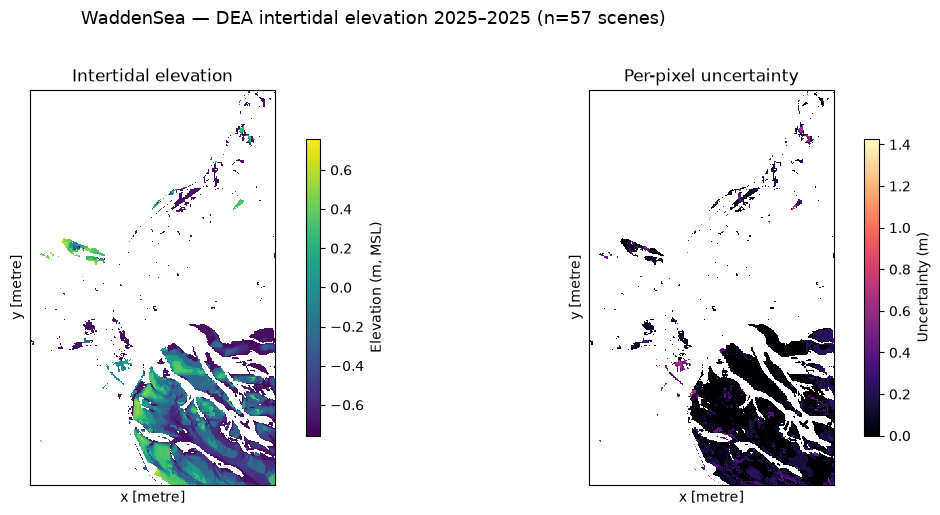

Saved: outputs/WaddenSea_elevation_map.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Panel 1: elevation ---
ds_elev["elevation"].plot.imshow(
    ax=axes[0], cmap="viridis",
    cbar_kwargs={"label": "Elevation (m, MSL)", "shrink": 0.75},
)
axes[0].set_title("Intertidal elevation")
axes[0].set_aspect("equal")
axes[0].set_xticks([]); axes[0].set_yticks([])

# --- Panel 2: uncertainty ---
if "elevation_uncertainty" in ds_elev:
    ds_elev["elevation_uncertainty"].plot.imshow(
        ax=axes[1], cmap="magma",
        cbar_kwargs={"label": "Uncertainty (m)", "shrink": 0.75},
    )
    axes[1].set_title("Per-pixel uncertainty")
else:
    axes[1].text(0.5, 0.5, "No uncertainty layer",
                 ha="center", va="center", transform=axes[1].transAxes)
axes[1].set_aspect("equal")
axes[1].set_xticks([]); axes[1].set_yticks([])

fig.suptitle(
    f"{SITE_NAME} — DEA intertidal elevation {START[:4]}–{END[:4]} (n={n_scenes} scenes)",
    fontsize=13, y=1.02,
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"{SITE_NAME}_elevation_map.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: outputs/{SITE_NAME}_elevation_map.png")

> **Reading Step 8:**
>
> | Panel | What to look for | Red flag |
> |---|---|---|
> | **Elevation** | Smooth gradient: channels low → upper flat high | Salt-and-pepper noise |
> | **Uncertainty** | Low on the central flats | High everywhere → poor sampling (Step 6) |
>
> Ask yourself:
> 1. Does the elevation pattern match the flats you saw on pages 5–6?
> 2. Is uncertainty **low** where you need heights for your research question?
> 3. High uncertainty at the flat **edges** only is normal; high uncertainty across the flat
>    **centre** means you should extend the date window.

## Step 9 — Quality-assurance maps

`elevation()` returns **QA layers** alongside the height. Together they show *where* the fit
is trustworthy and *why* some pixels fail — essential for deciding which pixels to keep when
you compute statistics or compare epochs.

| Layer | Meaning | What to look for |
|---|---|---|
| `elevation` | Sediment height (m, MSL) | Smooth intertidal gradient |
| `elevation_uncertainty` | Fit uncertainty (m) | Low on the central flats |
| `qa_ndwi_corr` | Correlation between NDWI and tide height | **Positive** on intertidal pixels (wet at high tide) |
| `qa_ndwi_freq` | Fraction of clear observations classified wet | ~0 on the upper flat, ~1 in channels |
| `qa_count_clear` | Number of clear satellite observations | Higher → more stable fit |

This is the same five-panel layout as the
[DEA development notebook](https://github.com/GeoscienceAustralia/dea-intertidal/blob/develop/notebooks/development/Intertidal_elevation.ipynb).

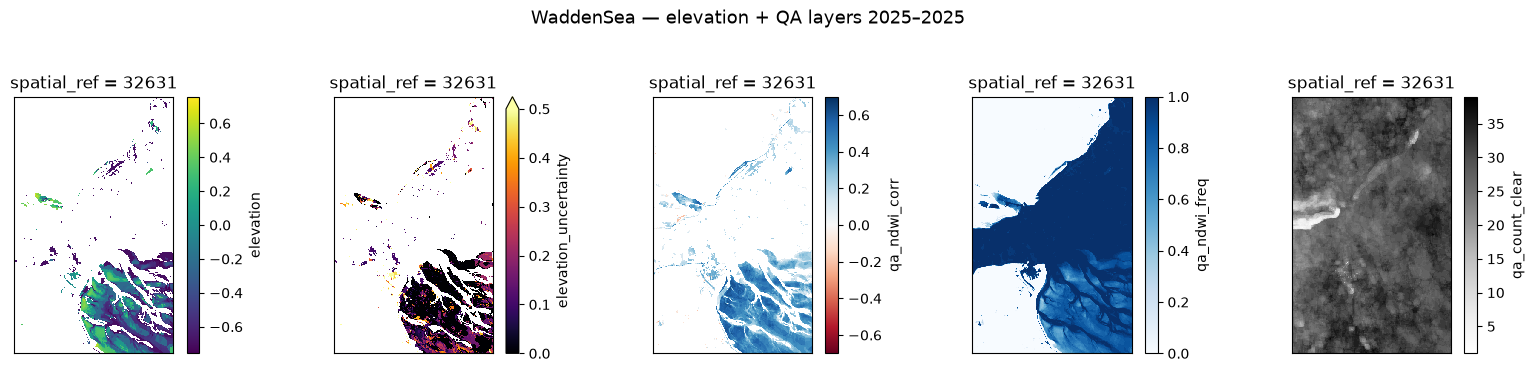

Saved: outputs/WaddenSea_elevation_qa.png


In [19]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))

# (variable, title, imshow kwargs) for each QA panel
layers = [
    ("elevation",             "Elevation (m, MSL)",   {"cmap": "viridis"}),
    ("elevation_uncertainty", "Uncertainty (m)",      {"cmap": "inferno", "vmin": 0, "vmax": 0.5}),
    ("qa_ndwi_corr",          "NDWI–tide correlation", {"cmap": "RdBu", "vmin": -0.7, "vmax": 0.7}),
    ("qa_ndwi_freq",          "Wet obs. frequency",    {"cmap": "Blues", "vmin": 0, "vmax": 1}),
    ("qa_count_clear",        "Clear obs. count",      {"cmap": "Greys"}),
]

for ax, (var, title, plot_kw) in zip(axes, layers):
    ax.set_title(title, fontsize=10)
    if var not in ds_elev:
        ax.text(0.5, 0.5, f"No {var}", ha="center", va="center", transform=ax.transAxes)
    else:
        ds_elev[var].plot.imshow(ax=ax, add_colorbar=True, **plot_kw)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel(""); ax.set_ylabel("")

fig.suptitle(
    f"{SITE_NAME} — elevation + QA layers {START[:4]}–{END[:4]}",
    fontsize=13, y=1.05,
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"{SITE_NAME}_elevation_qa.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: outputs/{SITE_NAME}_elevation_qa.png")

> **Reading Step 9:**
>
> | Panel | Good sign | Warning sign |
> |---|---|---|
> | **NDWI–tide correlation** | Positive on intertidal flats | Near zero everywhere → poor tidal sampling (Step 6) |
> | **Wet frequency** | Gradient from dry upper flat to wet channels | Uniform values → pixel never toggles wet/dry |
> | **Clear obs. count** | Dozens on the flats | Very low counts → noisy or missing elevation |
>
> Use these layers to **mask** unreliable pixels before exporting statistics — for example,
> keep only pixels with `qa_count_clear ≥ 20` and `elevation_uncertainty` below a threshold
> you choose for your application.

## Step 10 — Save outputs

| File | Format | Use |
|---|---|---|
| `*_elevation_*.nc` | NetCDF | Full dataset + QA layers (Python / xarray) |
| `*_elevation_*.tif` | GeoTIFF | Elevation band for QGIS / ArcGIS |

The NetCDF keeps everything; the GeoTIFF is a single elevation band for GIS software.

In [20]:
# Full dataset (elevation + all QA layers) as NetCDF
out_nc = OUTPUT_DIR / f"{SITE_NAME}_elevation_{START[:4]}_{END[:4]}.nc"
ds_elev.to_netcdf(out_nc)
print(f"Wrote: {out_nc}")

# Single-band GeoTIFF for GIS — needs rioxarray and a CRS on the array
try:
    tif = OUTPUT_DIR / f"{SITE_NAME}_elevation_{START[:4]}_{END[:4]}.tif"
    ds_elev["elevation"].rio.to_raster(tif)
    print(f"Wrote: {tif}")
except Exception as e:
    print("GeoTIFF export skipped:", e)

Wrote: outputs/WaddenSea_elevation_2025_2025.nc
Wrote: outputs/WaddenSea_elevation_2025_2025.tif


## Step 11 — Summary

You have produced a complete intertidal elevation dataset in six layers:

1. **Year caches (Step 5)** — NDWI per sensor × year (`ndwi_<landsat|s2>_<year>.zarr`), merged for the fit.
2. **Tidal sampling (Step 6)** — scene dots on the FES2022 curve (HAT/LAT/HOT/LOT).
3. **Elevation fit (Step 7)** — DEA `elevation()` with FES2022 tide tags.
4. **Maps (Step 8)** — height + uncertainty side by side.
5. **QA maps (Step 9)** — NDWI–tide correlation, wet frequency, clear count.
6. **Exports (Step 10)** — NetCDF + GeoTIFF for downstream use.

### Output files (all in `outputs/`)

| File | Content |
|---|---|
| `<site>_tidal_sampling_elevation.png` | Tide curve + scene dots |
| `<site>_elevation_map.png` | Elevation + uncertainty (2 panels) |
| `<site>_elevation_qa.png` | Elevation + full QA stack (5 panels) |
| `<site>_elevation_YYYY_YYYY.nc` | Full elevation dataset + QA |
| `<site>_elevation_YYYY_YYYY.tif` | Elevation GeoTIFF for GIS |

---

**You have finished the six tutorial pages.** Continue to
**[Applications & next steps](07_applications.md)** for project ideas — time series, ecological
monitoring, shapefile-based analysis — or **[Cleanup](07_cleanup.md)** to remove the local install.

`Setup → Connect → Tides → Validation → NDWI → `**`Elevation`**` → your project`